In [89]:
import torch
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
import pandas as pd
from sklearn.preprocessing import StandardScaler
from pathlib import Path

In [65]:
class SigmaPredictor(nn.Module):
    def __init__(self, in_dim = 5, hidden = 64, out_dim = 5):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(in_dim, hidden),
            nn.GELU(),
            nn.Linear(hidden, hidden),
            nn.GELU(),
            nn.Linear(hidden, hidden // 2),
            nn.GELU(),
            nn.Linear(hidden // 2, out_dim),
        )
    
    def forward(self, x):
        return self.net(x)

In [66]:
torch.manual_seed(100)
model_0 = SigmaPredictor()
opt = torch.optim.Adam(model_0.parameters(), lr=1e-3, weight_decay=1e-4)
loss_fn = nn.SmoothL1Loss()

In [67]:
#loading data from csv files
df = pd.read_csv("data/dataset.csv")
df.head(10)
feature_col = ['z_l', 'z_s1', 'z_s2', 'sig_b', 'beta']
target_col = ['w0_sigma', 'wa_sigma', 'w0_mean', 'wa_mean', 'OmM_mean']
X = df[feature_col].values
y = df[target_col].values
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=100
)

In [68]:
x_scaler = StandardScaler().fit(X_train)
X_train = x_scaler.transform(X_train)
X_test  = x_scaler.transform(X_test)
y_scaler = StandardScaler().fit(y_train)

In [69]:
X_train = torch.tensor(X_train, dtype=torch.float32)
X_test  = torch.tensor(X_test,  dtype=torch.float32)
y_train = torch.tensor(y_scaler.transform(y_train), dtype=torch.float32)
y_test  = torch.tensor(y_scaler.transform(y_test),  dtype=torch.float32)

In [70]:
epochs = 600

for epoch in range(epochs):
    model_0.train()
    opt.zero_grad()
    pred = model_0(X_train)
    loss = loss_fn(pred, y_train)
    loss.backward()
    opt.step()

    model_0.eval()

    with torch.inference_mode():
        test_preds = model_0(X_test)
        test_loss = loss_fn(test_preds, y_test)

    if epoch % 10 == 0:
        print(f"epoch: {epoch}, loss = {loss}, test_loss = {test_loss}")


epoch: 0, loss = 0.166985422372818, test_loss = 0.254177987575531
epoch: 10, loss = 0.15461847186088562, test_loss = 0.24222037196159363
epoch: 20, loss = 0.14421267807483673, test_loss = 0.23187308013439178
epoch: 30, loss = 0.1396089494228363, test_loss = 0.22572411596775055
epoch: 40, loss = 0.1348649263381958, test_loss = 0.21883660554885864
epoch: 50, loss = 0.12993623316287994, test_loss = 0.21199065446853638
epoch: 60, loss = 0.12464521080255508, test_loss = 0.2044074684381485
epoch: 70, loss = 0.11898066103458405, test_loss = 0.19579960405826569
epoch: 80, loss = 0.11306329071521759, test_loss = 0.18702958524227142
epoch: 90, loss = 0.10672666132450104, test_loss = 0.17763815820217133
epoch: 100, loss = 0.09976298362016678, test_loss = 0.16758929193019867
epoch: 110, loss = 0.09180127084255219, test_loss = 0.15635830163955688
epoch: 120, loss = 0.08297214657068253, test_loss = 0.14349514245986938
epoch: 130, loss = 0.07361648231744766, test_loss = 0.1290607899427414
epoch: 140,

In [71]:
model_0.eval()

sig_b_idx = feature_col.index('sig_b')  # find its column position

def sensitivity_at_point(x_row_scaled):
    """x_row_scaled: 1D tensor, already in scaled feature space"""
    x = x_row_scaled.clone().detach().requires_grad_(True)
    pred = model_0(x.unsqueeze(0))  # shape (1, 5)

    grads = []
    for i in range(pred.shape[1]):
        grad = torch.autograd.grad(pred[0, i], x, retain_graph=True)[0]
        grads.append(grad[sig_b_idx].item())
    return dict(zip(target_col, grads))


In [72]:
x_sample = X_test[0]
print(sensitivity_at_point(x_sample))

{'w0_sigma': -0.01650959812104702, 'wa_sigma': -0.001755107194185257, 'w0_mean': -0.008330951444804668, 'wa_mean': 0.02128874883055687, 'OmM_mean': -0.0159488245844841}


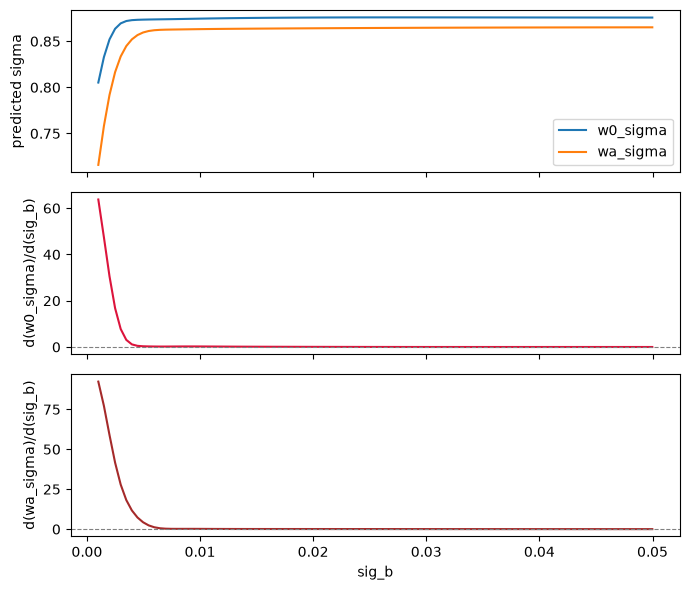

In [83]:
X_train_raw = x_scaler.inverse_transform(X_train.numpy())
baseline_raw = np.median(X_train_raw, axis=0)

sig_b_raw_range = np.linspace(X_train_raw[:, sig_b_idx].min(),
                                X_train_raw[:, sig_b_idx].max(), 100)

preds_raw = []
grads_w0_raw = []
grads_wa_raw = []

for sb in sig_b_raw_range:
    x_raw = baseline_raw.copy()
    x_raw[sig_b_idx] = sb
    x_scaled = x_scaler.transform(x_raw.reshape(1, -1))[0]

    x_t = torch.tensor(x_scaled, dtype=torch.float32, requires_grad=True)
    pred_scaled = model_0(x_t.unsqueeze(0))
    pred_raw = y_scaler.inverse_transform(pred_scaled.detach().numpy())[0]
    preds_raw.append(pred_raw)

    grad_w0 = torch.autograd.grad(pred_scaled[0, 0], x_t, retain_graph=True)[0][sig_b_idx].item()
    grad_w0_raw = grad_w0 * y_scaler.scale_[0] / x_scaler.scale_[sig_b_idx]
    grads_w0_raw.append(grad_w0_raw)

    grad_wa = torch.autograd.grad(pred_scaled[0, 1], x_t)[0][sig_b_idx].item()
    grad_wa_raw = grad_wa * y_scaler.scale_[1] / x_scaler.scale_[sig_b_idx]
    grads_wa_raw.append(grad_wa_raw)

preds_raw = np.array(preds_raw)

fig, axs = plt.subplots(3, 1, figsize=(7, 6), sharex=True)
axs[0].plot(sig_b_raw_range, preds_raw[:, 0], label='w0_sigma')
axs[0].plot(sig_b_raw_range, preds_raw[:, 1], label='wa_sigma')
axs[0].set_ylabel('predicted sigma')
axs[0].legend()

axs[1].plot(sig_b_raw_range, grads_w0_raw, color='crimson')
axs[1].axhline(0, color='gray', linestyle='--', linewidth=0.8)
axs[1].set_ylabel('d(w0_sigma)/d(sig_b)')

axs[2].plot(sig_b_raw_range, grads_wa_raw, color='brown')
axs[2].axhline(0, color='gray', linestyle='--', linewidth=0.8)
axs[2].set_ylabel('d(wa_sigma)/d(sig_b)')
axs[2].set_xlabel('sig_b')

plt.tight_layout()
plt.show()

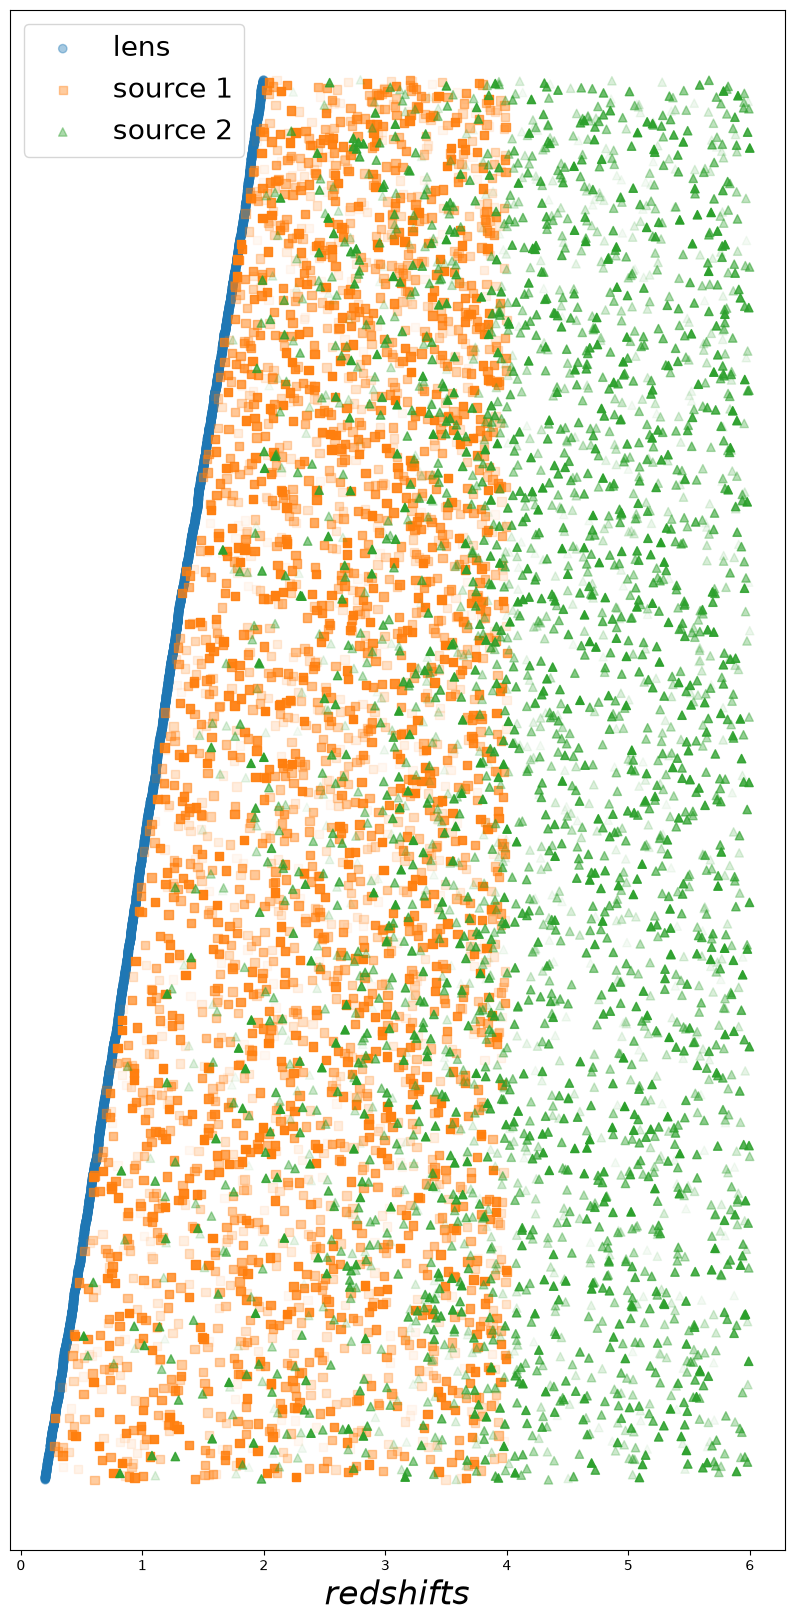

In [86]:
import numpy as np
import matplotlib.pyplot as plt

df_sorted = df.sort_values(by='z_l').reset_index(drop=True)

zl_sort    = df_sorted['z_l'].values
zs1_sort   = df_sorted['z_s1'].values
zs2_sort   = df_sorted['z_s2'].values
sig_b_sort = df_sorted['sig_b'].values

num = len(df_sorted)
i = np.linspace(0, num, num)

# normalize sig_b to [0, 1], then invert so bigger sig_b -> lower alpha (lighter)
sig_b_norm = (sig_b_sort - sig_b_sort.min()) / (sig_b_sort.max() - sig_b_sort.min())
alphas = 1 - sig_b_norm
alphas = np.clip(alphas, 0.05, 1.0)  # keep a floor so points don't vanish completely

plt.subplots(figsize=(10, 20))
plt.tick_params(left=False, labelleft=False)

plt.scatter(zl_sort,  i, marker="o", label="lens",     alpha=alphas, color="tab:blue")
plt.scatter(zs1_sort, i, marker="s", label="source 1", alpha=alphas, color="tab:orange")
plt.scatter(zs2_sort, i, marker="^", label="source 2", alpha=alphas, color="tab:green")

plt.xlabel("$redshifts$", fontsize=24)
plt.legend(fontsize=20)
plt.show()

In [87]:
print(df['sig_b'].describe())

count    3000.000000
mean        0.025269
std         0.014045
min         0.001009
25%         0.012806
50%         0.025346
75%         0.037469
max         0.049981
Name: sig_b, dtype: float64


In [90]:
MODEL_DIC = Path("models")
MODEL_DIC.mkdir(parents=True, exist_ok=True)

In [93]:
SAVE_PATH = MODEL_DIC / 'model_0.pth'
torch.save(model_0.state_dict(), SAVE_PATH)

In [92]:
model_0.state_dict()

OrderedDict([('net.0.weight',
              tensor([[-1.2440e-01,  1.9116e-01, -1.1757e-01,  6.0954e-02,  1.0095e-01],
                      [ 1.5804e-01, -3.0154e-01, -2.7152e-01, -5.1046e-01, -3.5437e-01],
                      [-2.6466e-01,  1.2336e-01,  3.2063e-01,  1.6547e-01, -1.1747e-02],
                      [ 6.3017e-01,  5.2925e-01,  1.7838e-01, -4.9622e-01, -2.1945e-01],
                      [-1.6360e-01,  1.7562e-01,  2.6037e-01,  2.6724e-01, -3.1430e-02],
                      [ 6.4603e-01,  4.5464e-01,  5.2142e-02, -4.8344e-01,  9.1204e-02],
                      [-1.8447e-01, -2.9744e-01,  2.5644e-01, -2.6809e-01, -3.9117e-01],
                      [-2.5814e-01,  1.2050e-01,  1.2270e-01, -5.4247e-01,  2.4714e-01],
                      [-3.1076e-01, -5.2891e-01,  3.6403e-01, -2.2123e-01, -2.4633e-01],
                      [ 9.2416e-03, -5.3211e-01,  1.1041e-02,  2.9170e-01, -1.6914e-02],
                      [ 2.2490e-01,  1.9495e-01, -5.5990e-02, -3.7969e-01,  1.09